<a href="https://colab.research.google.com/github/Sarmentum/ML_TestGoogleCollab/blob/main/notebook2_xgboost_aerosol_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning for Aerosol Scientists
## Part 1: XGBoost for UVLIF Aerosol Classification

### Learning Objectives
By the end of this notebook, you will understand:
1. Train/test/validation splits and why they matter
2. Model evaluation using ROC curves and other metrics
3. Hyperparameter tuning to optimize model performance
4. How to apply gradient boosting (XGBoost) to classify aerosol types

### Background
UVLIF mass spectrometry generates fluorescence spectra that can distinguish between different aerosol types (biological, mineral dust, organic carbon, etc.). We'll use machine learning to automate this classification.

## Exercise: Repeat Workflow with 'Harder' Data

As instructed, we will now repeat the workflow using the `generate_uvlif_spectrum_hard` function to create a more challenging dataset. This will involve re-generating the data, re-splitting it into train/validation/test sets, and re-applying scaling and label encoding.

In [81]:
# Re-generate dataset with 'harder' spectra

np.random.seed(42) # Ensure reproducibility
n_samples_per_class_hard = 250 # Using the same number of samples per class

data_hard = []
labels_hard = []

for aerosol_type in aerosol_types:
    for _ in range(n_samples_per_class_hard):
        spectrum = generate_uvlif_spectrum_hard(aerosol_type) # <--- Using the 'hard' function
        data_hard.append(spectrum)
        labels_hard.append(aerosol_type)

# Convert to arrays
X_hard = np.array(data_hard)
y_hard = np.array(labels_hard)

print(f"New Dataset shape: {X_hard.shape}")
print(f"Classes: {aerosol_types}")
print(f"Samples per class: {n_samples_per_class_hard}")

New Dataset shape: (1000, 64)
Classes: ['biological', 'mineral_dust', 'organic_carbon', 'pah']
Samples per class: 250


### Visualize example spectra for the 'hard' dataset

Let's visualize some of the newly generated 'hard' spectra to see the increased overlap and noise.

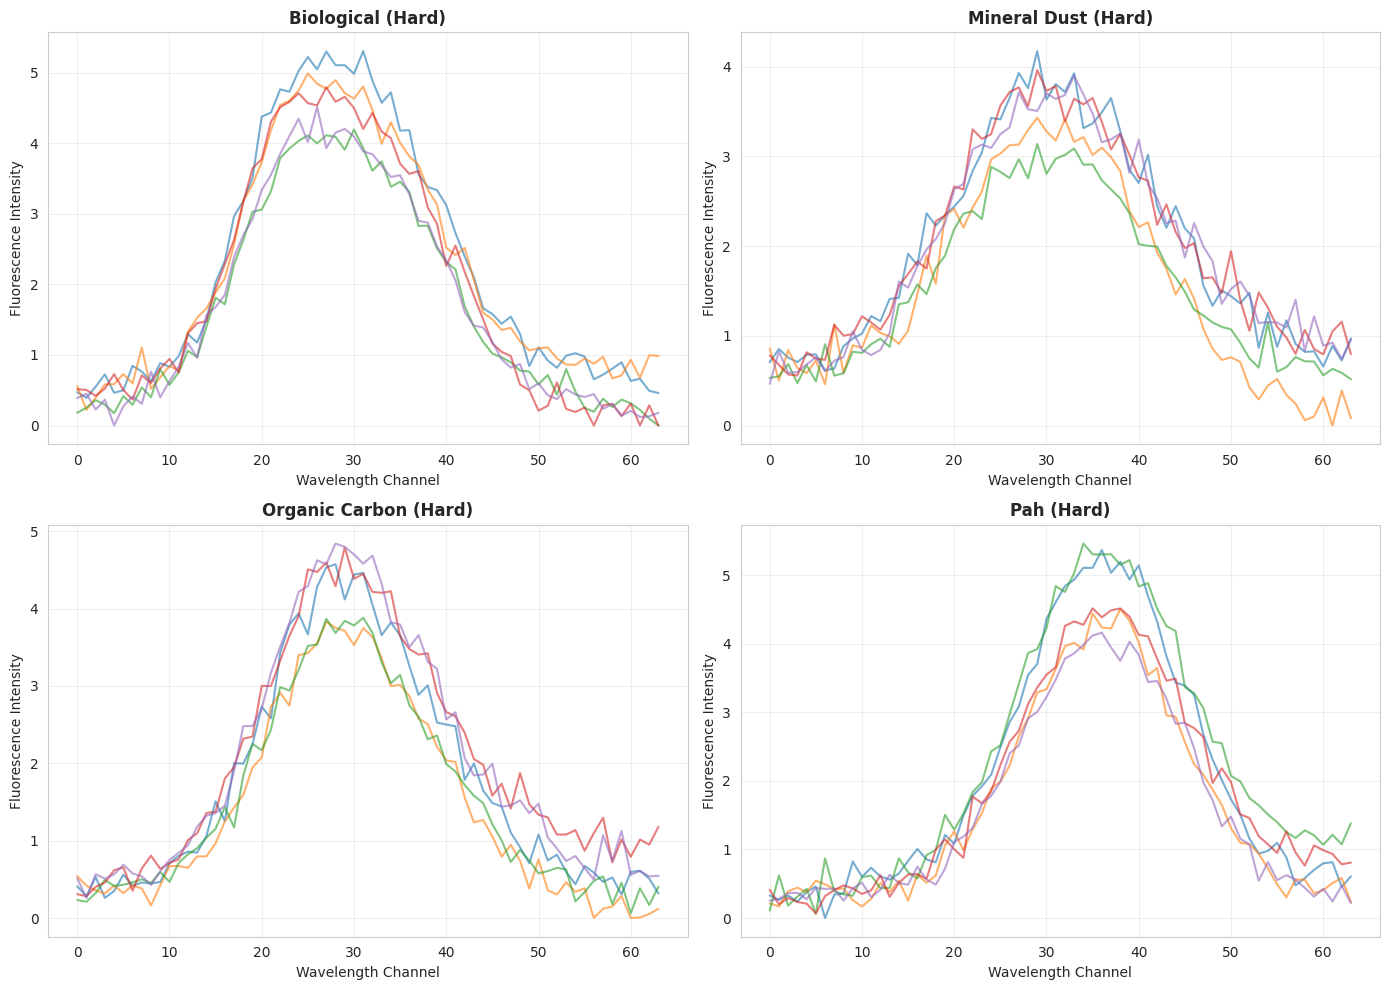

Note the increased overlap and noise compared to the 'easy' dataset.


In [82]:
# Visualize example spectra for each aerosol type in the 'hard' dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, aerosol_type in enumerate(aerosol_types):
    # Get indices for this class
    class_indices = np.where(y_hard == aerosol_type)[0]

    # Plot several examples
    for i in range(5):
        axes[idx].plot(X_hard[class_indices[i]], alpha=0.6, linewidth=1.5)

    axes[idx].set_title(f'{aerosol_type.replace("_", " ").title()} (Hard)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Wavelength Channel', fontsize=10)
    axes[idx].set_ylabel('Fluorescence Intensity', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('example_spectra_hard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note the increased overlap and noise compared to the 'easy' dataset.")

### Re-perform Train/Test/Validation Split for 'Hard' Data

Now, we'll re-split the `X_hard` and `y_hard` data into training, validation, and test sets, following the same proportions as before.

In [83]:
# First split: separate out test set (20%) for 'hard' data
X_temp_hard, X_test_hard, y_temp_hard, y_test_hard = train_test_split(
    X_hard, y_hard, test_size=0.2, random_state=42, stratify=y_hard
)

# Second split: divide remaining data into train (60%) and validation (20%) for 'hard' data
X_train_hard, X_val_hard, y_train_hard, y_val_hard = train_test_split(
    X_temp_hard, y_temp_hard, test_size=0.25, random_state=42, stratify=y_temp_hard
)

print("Data splits for 'Hard' dataset:")
print(f"Training set: {X_train_hard.shape[0]} samples ({X_train_hard.shape[0]/len(X_hard)*100:.1f}%) ")
print(f"Validation set: {X_val_hard.shape[0]} samples ({X_val_hard.shape[0]/len(X_hard)*100:.1f}%) ")
print(f"Test set: {X_test_hard.shape[0]} samples ({X_test_hard.shape[0]/len(X_hard)*100:.1f}%) ")
print("\n✓ Test set is locked away - we won't touch it until final evaluation!")

Data splits for 'Hard' dataset:
Training set: 600 samples (60.0%) 
Validation set: 200 samples (20.0%) 
Test set: 200 samples (20.0%) 

✓ Test set is locked away - we won't touch it until final evaluation!


### Feature Scaling and Label Encoding for 'Hard' Data

We also need to re-scale the features and re-encode the labels for the new dataset.

In [84]:
# Feature scaling - fit scaler on training data only!
scaler_hard = StandardScaler()
X_train_scaled_hard = scaler_hard.fit_transform(X_train_hard)
X_val_scaled_hard = scaler_hard.transform(X_val_hard)
X_test_scaled_hard = scaler_hard.transform(X_test_hard)

# Encode labels
label_encoder_hard = LabelEncoder()
y_train_encoded_hard = label_encoder_hard.fit_transform(y_train_hard)
y_val_encoded_hard = label_encoder_hard.transform(y_val_hard)
y_test_encoded_hard = label_encoder_hard.transform(y_test_hard)

print("✓ 'Hard' data scaled and labels encoded")
print("\nNow you can proceed to re-run the 'Train a Baseline XGBoost Model' section (Step 3) and subsequent steps, using these new variables (`X_train_scaled_hard`, `y_train_encoded_hard`, etc.) to evaluate performance on the harder dataset.")

✓ 'Hard' data scaled and labels encoded

Now you can proceed to re-run the 'Train a Baseline XGBoost Model' section (Step 3) and subsequent steps, using these new variables (`X_train_scaled_hard`, `y_train_encoded_hard`, etc.) to evaluate performance on the harder dataset.


In [85]:
# Install required packages
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy -q

In [86]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Generate Synthetic UVLIF Data

We'll create synthetic aerosol mass spectra for 4 aerosol types:
- **Biological**: Strong fluorescence at specific wavelengths (characteristic of proteins/NAD(P)H)
- **Mineral Dust**: Weak, broad fluorescence
- **Organic Carbon**: Moderate fluorescence with different spectral features
- **Polycyclic Aromatic Hydrocarbons (PAH)**: Strong fluorescence at longer wavelengths

In [87]:
def generate_uvlif_spectrum(aerosol_type, n_wavelengths=64, noise_level=0.1):
    """
    Generate synthetic UVLIF spectrum for different aerosol types.

    Parameters:
    -----------
    aerosol_type : str
        Type of aerosol ('biological', 'mineral_dust', 'organic_carbon', 'pah')
    n_wavelengths : int
        Number of spectral channels (wavelength bins)
    noise_level : float
        Amount of random noise to add
    """
    wavelengths = np.linspace(0, 1, n_wavelengths)

    if aerosol_type == 'biological':
        # Two peaks: tryptophan-like (~280nm) and NAD(P)H-like (~340-460nm)
        spectrum = (3.0 * np.exp(-((wavelengths - 0.3)**2) / 0.01) +
                   4.0 * np.exp(-((wavelengths - 0.5)**2) / 0.02))

    elif aerosol_type == 'mineral_dust':
        # Weak, broad, nearly flat response
        spectrum = 0.5 + 0.3 * np.exp(-((wavelengths - 0.5)**2) / 0.5)

    elif aerosol_type == 'organic_carbon':
        # Single broader peak in mid-range
        spectrum = 2.5 * np.exp(-((wavelengths - 0.4)**2) / 0.03)

    elif aerosol_type == 'pah':
        # Strong peak at longer wavelengths
        spectrum = 5.0 * np.exp(-((wavelengths - 0.7)**2) / 0.02)

    # Add realistic noise
    noise = noise_level * np.random.randn(n_wavelengths)
    spectrum = spectrum + noise

    # Ensure non-negative (like real fluorescence data)
    spectrum = np.maximum(spectrum, 0)

    return spectrum

# Generate dataset
np.random.seed(42)
n_samples_per_class = 250
aerosol_types = ['biological', 'mineral_dust', 'organic_carbon', 'pah']

data = []
labels = []

for aerosol_type in aerosol_types:
    for _ in range(n_samples_per_class):
        spectrum = generate_uvlif_spectrum(aerosol_type)
        data.append(spectrum)
        labels.append(aerosol_type)

# Convert to arrays
X = np.array(data)
y = np.array(labels)

print(f"Dataset shape: {X.shape}")
print(f"Classes: {aerosol_types}")
print(f"Samples per class: {n_samples_per_class}")

Dataset shape: (1000, 64)
Classes: ['biological', 'mineral_dust', 'organic_carbon', 'pah']
Samples per class: 250


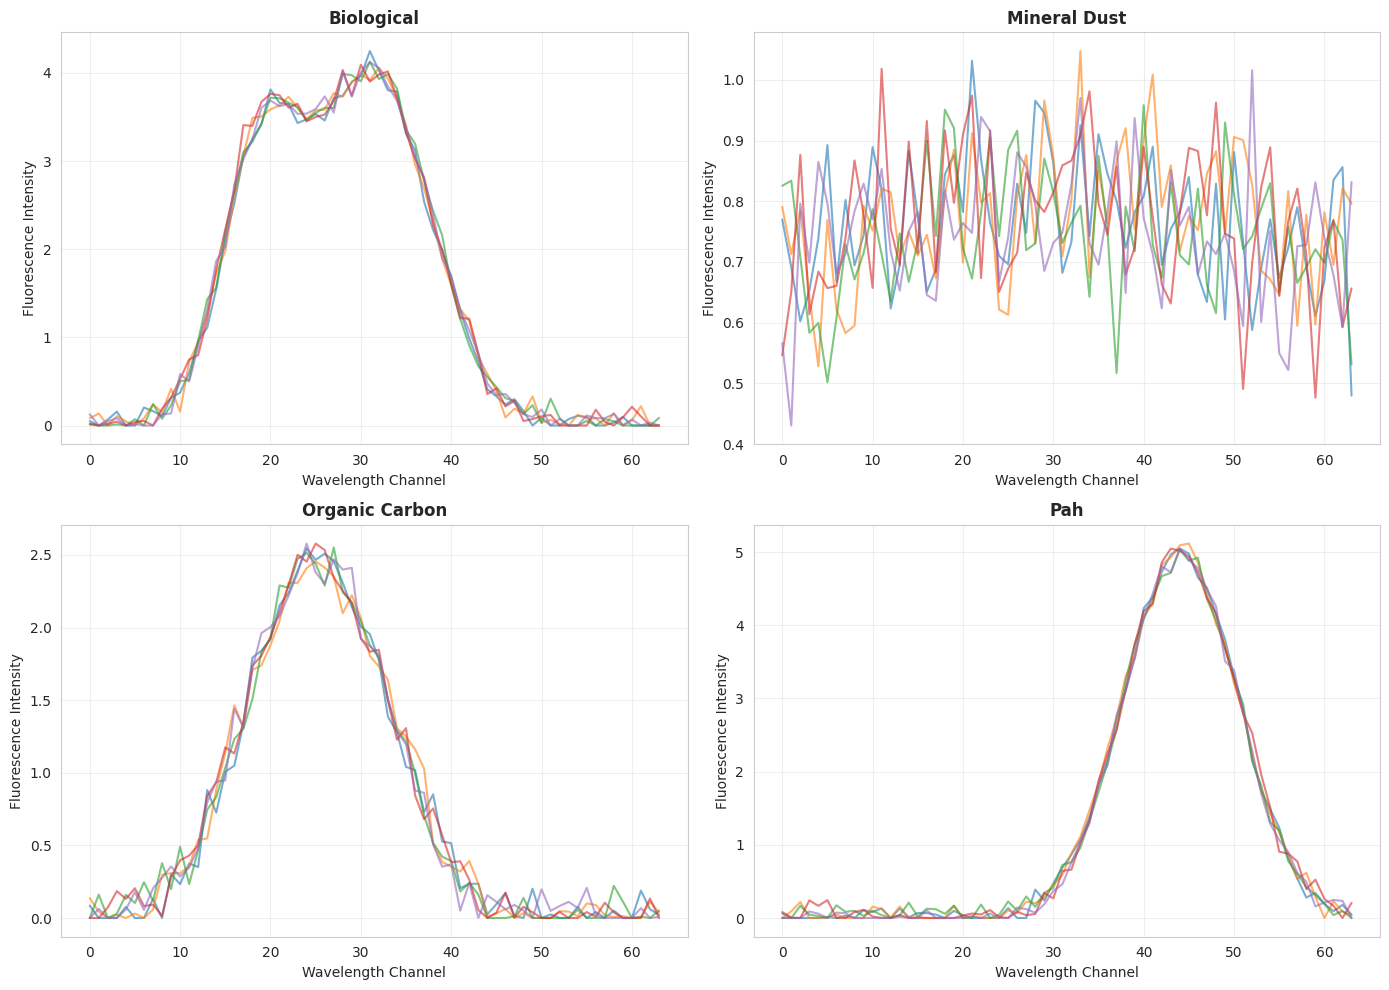

Note the characteristic spectral signatures:
- Biological: Two distinct peaks (proteins and NAD(P)H)
- Mineral Dust: Weak, broad response
- Organic Carbon: Single moderate peak
- PAH: Strong peak at longer wavelengths


In [88]:
# Visualize example spectra for each aerosol type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, aerosol_type in enumerate(aerosol_types):
    # Get indices for this class
    class_indices = np.where(y == aerosol_type)[0]

    # Plot several examples
    for i in range(5):
        axes[idx].plot(X[class_indices[i]], alpha=0.6, linewidth=1.5)

    axes[idx].set_title(f'{aerosol_type.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Wavelength Channel', fontsize=10)
    axes[idx].set_ylabel('Fluorescence Intensity', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('example_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note the characteristic spectral signatures:")
print("- Biological: Two distinct peaks (proteins and NAD(P)H)")
print("- Mineral Dust: Weak, broad response")
print("- Organic Carbon: Single moderate peak")
print("- PAH: Strong peak at longer wavelengths")

## Step 2: Train/Test/Validation Split

### Why do we need multiple data splits?

1. **Training Set (60%)**: Used to train the model (learn patterns)
2. **Validation Set (20%)**: Used to tune hyperparameters and make decisions during model development
3. **Test Set (20%)**: Held out completely until the end - gives unbiased estimate of real-world performance

**Critical concept**: The test set must NEVER be used during model development. It's your "honest estimate" of how the model will perform on new, unseen aerosol samples.

In [89]:
# First split: separate out test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: divide remaining data into train (75% of 80% = 60%) and validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Data splits:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print("\n✓ Test set is locked away - we won't touch it until final evaluation!")

Data splits:
Training set: 600 samples (60.0%)
Validation set: 200 samples (20.0%)
Test set: 200 samples (20.0%)

✓ Test set is locked away - we won't touch it until final evaluation!


In [90]:
# Feature scaling - important for many ML algorithms
# Fit scaler on training data only!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("✓ Data scaled and labels encoded")

✓ Data scaled and labels encoded


## Step 3: Train a Baseline XGBoost Model

**What is XGBoost?**
- Gradient Boosting algorithm: builds an ensemble of decision trees sequentially
- Each new tree corrects errors made by previous trees
- Very effective for tabular/structured data (like spectra)
- Popular in competitions and real-world applications

In [91]:
# Train baseline model with default parameters
baseline_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'  # multiclass log loss
)

baseline_model.fit(X_train_scaled_hard, y_train_encoded_hard)

# Evaluate on validation set
val_predictions = baseline_model.predict(X_val_scaled_hard)
val_accuracy = (val_predictions == y_val_encoded_hard).mean()

print(f"Baseline Model Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print("\nClassification Report (Validation Set):")
print(classification_report(y_val_encoded_hard, val_predictions,
                          target_names=label_encoder_hard.classes_))

Baseline Model Validation Accuracy: 0.9950 (99.50%)

Classification Report (Validation Set):
                precision    recall  f1-score   support

    biological       1.00      1.00      1.00        50
  mineral_dust       0.98      1.00      0.99        50
organic_carbon       1.00      0.98      0.99        50
           pah       1.00      1.00      1.00        50

      accuracy                           0.99       200
     macro avg       1.00      0.99      0.99       200
  weighted avg       1.00      0.99      0.99       200



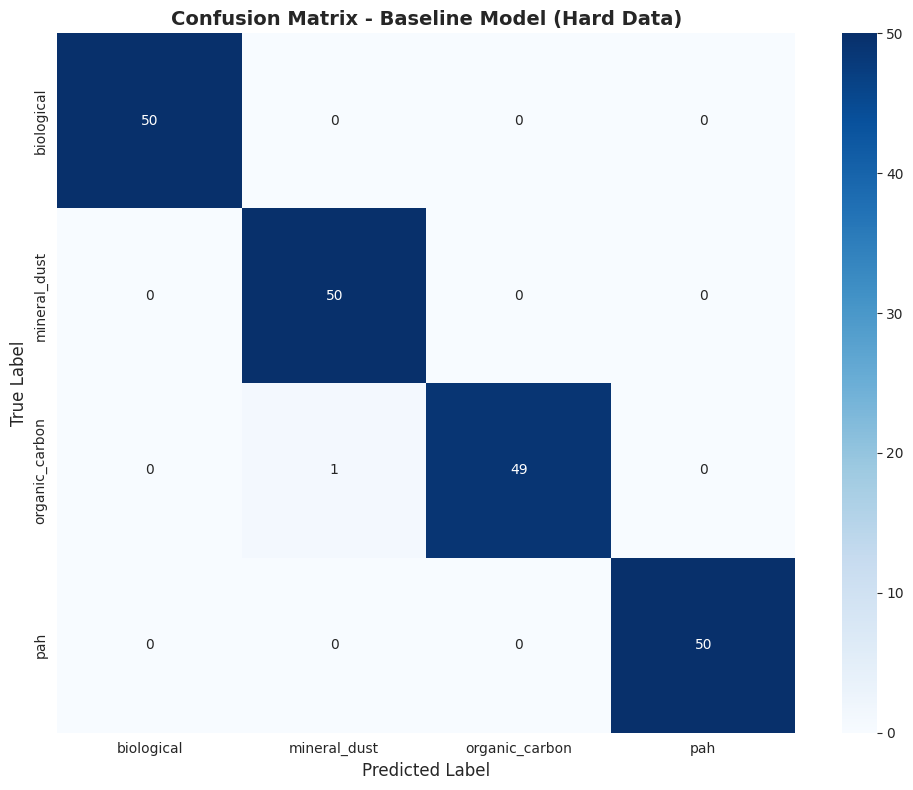


How to read this: Diagonal = correct predictions, Off-diagonal = errors


In [92]:
# Confusion Matrix
cm = confusion_matrix(y_val_encoded_hard, val_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_hard.classes_,
            yticklabels=label_encoder_hard.classes_)
plt.title('Confusion Matrix - Baseline Model (Hard Data)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_baseline_hard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHow to read this: Diagonal = correct predictions, Off-diagonal = errors")

## Step 4: ROC Curves and AUC

**Receiver Operating Characteristic (ROC) curves** show the trade-off between:
- **True Positive Rate (Sensitivity)**: Correctly identifying aerosol type
- **False Positive Rate**: Incorrectly classifying other types as this type

**Area Under Curve (AUC)**:
- AUC = 1.0: Perfect classifier
- AUC = 0.5: Random guessing
- AUC > 0.9: Excellent performance

For multi-class problems, we compute one ROC curve per class (one-vs-rest approach).

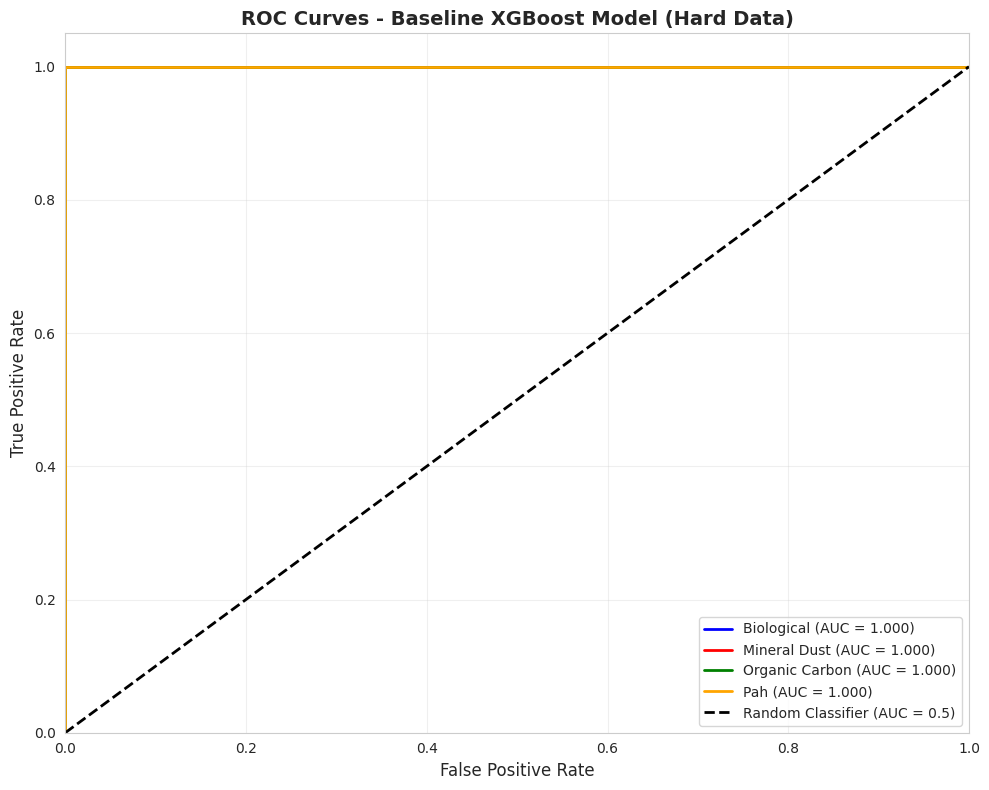


Interpretation:
- Curves closer to top-left corner = better performance
- AUC closer to 1.0 = better discrimination ability
- Mean AUC across classes: 1.000


In [93]:
# Get probability predictions
y_val_proba = baseline_model.predict_proba(X_val_scaled_hard)

# Binarize labels for ROC curve (one-vs-rest)
y_val_bin = label_binarize(y_val_encoded_hard, classes=range(len(aerosol_types)))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(aerosol_types)):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for i, (color, aerosol_type) in enumerate(zip(colors, aerosol_types)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{aerosol_type.replace("_", " ").title()} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Baseline XGBoost Model (Hard Data)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_baseline_hard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Curves closer to top-left corner = better performance")
print("- AUC closer to 1.0 = better discrimination ability")
print(f"- Mean AUC across classes: {np.mean(list(roc_auc.values())):.3f}")

## Step 5: Hyperparameter Tuning

**Hyperparameters** are settings that control the learning process (not learned from data).

Key XGBoost hyperparameters:
- **n_estimators**: Number of trees (more trees = more complex model)
- **max_depth**: Maximum depth of each tree (deeper = more complex)
- **learning_rate**: How much each tree contributes (smaller = more conservative)
- **subsample**: Fraction of samples used for each tree (prevents overfitting)

We use **Grid Search** with **Cross-Validation** to find the best combination.

In [95]:
# Define parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

print(f"Testing {np.prod([len(v) for v in param_grid.values()])} parameter combinations...")
print("This may take a few minutes...\n")

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Fit on training data
grid_search.fit(X_train_scaled_hard, y_train_encoded_hard)

print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Baseline Validation Score: {val_accuracy:.4f}")
print(f"\nImprovement: {(grid_search.best_score_ - val_accuracy)*100:.2f} percentage points")

Testing 54 parameter combinations...
This may take a few minutes...

Fitting 5 folds for each of 54 candidates, totalling 270 fits

HYPERPARAMETER TUNING RESULTS

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Score: 0.9800
Baseline Validation Score: 0.9950

Improvement: -1.50 percentage points


In [96]:
# Get best model
best_model = grid_search.best_estimator_

# Evaluate on validation set
val_predictions_tuned = best_model.predict(X_val_scaled_hard)
val_accuracy_tuned = (val_predictions_tuned == y_val_encoded_hard).mean()

print("\nTuned Model Performance:")
print("="*60)
print(f"Validation Accuracy: {val_accuracy_tuned:.4f} ({val_accuracy_tuned*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_val_encoded_hard, val_predictions_tuned,
                          target_names=label_encoder_hard.classes_))


Tuned Model Performance:
Validation Accuracy: 1.0000 (100.00%)

Classification Report:
                precision    recall  f1-score   support

    biological       1.00      1.00      1.00        50
  mineral_dust       1.00      1.00      1.00        50
organic_carbon       1.00      1.00      1.00        50
           pah       1.00      1.00      1.00        50

      accuracy                           1.00       200
     macro avg       1.00      1.00      1.00       200
  weighted avg       1.00      1.00      1.00       200



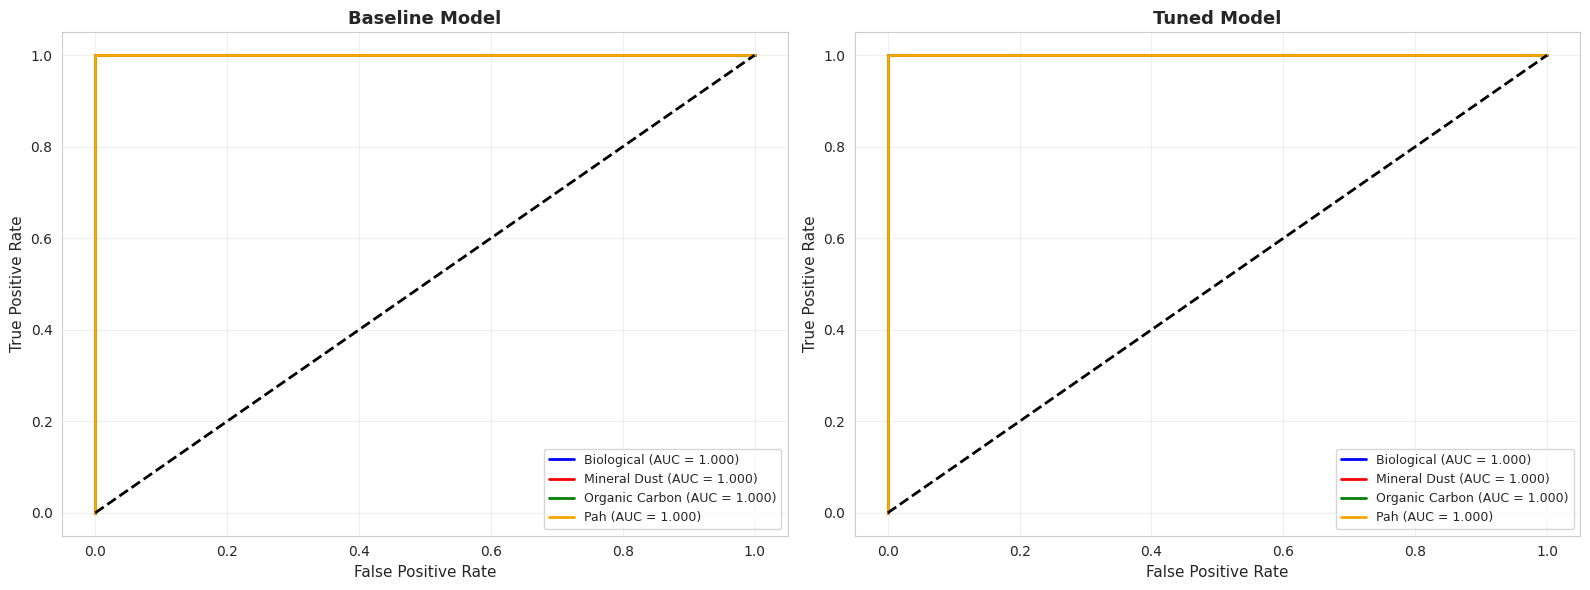

In [97]:
# Compare ROC curves: Baseline vs Tuned
y_val_proba_tuned = best_model.predict_proba(X_val_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for baseline
for i, (color, aerosol_type) in enumerate(zip(colors, aerosol_types)):
    fpr_base, tpr_base, _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc_base = auc(fpr_base, tpr_base)
    axes[0].plot(fpr_base, tpr_base, color=color, lw=2,
                label=f'{aerosol_type.replace("_", " ").title()} (AUC = {roc_auc_base:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Baseline Model', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot for tuned model
for i, (color, aerosol_type) in enumerate(zip(colors, aerosol_types)):
    fpr_tuned, tpr_tuned, _ = roc_curve(y_val_bin[:, i], y_val_proba_tuned[:, i])
    roc_auc_tuned = auc(fpr_tuned, tpr_tuned)
    axes[1].plot(fpr_tuned, tpr_tuned, color=color, lw=2,
                label=f'{aerosol_type.replace("_", " ").title()} (AUC = {roc_auc_tuned:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Tuned Model', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Final Evaluation on Test Set

**NOW** we can use our held-out test set for final evaluation. This gives us an honest estimate of real-world performance.

FINAL TEST SET EVALUATION

Test Set Accuracy: 1.0000 (100.00%)

Classification Report:
                precision    recall  f1-score   support

    biological       1.00      1.00      1.00        50
  mineral_dust       1.00      1.00      1.00        50
organic_carbon       1.00      1.00      1.00        50
           pah       1.00      1.00      1.00        50

      accuracy                           1.00       200
     macro avg       1.00      1.00      1.00       200
  weighted avg       1.00      1.00      1.00       200



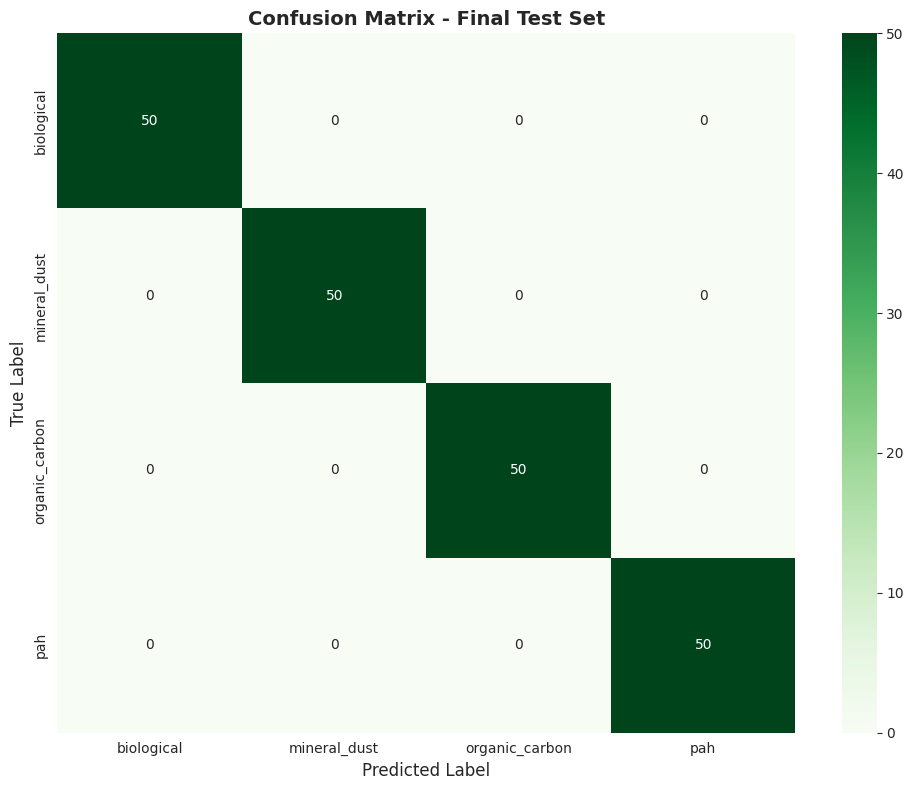

In [98]:
# Final evaluation on test set
test_predictions = best_model.predict(X_test_scaled)
test_accuracy = (test_predictions == y_test_encoded).mean()

print("="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)
print(f"\nTest Set Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test_encoded, test_predictions,
                          target_names=label_encoder.classes_))

# Test set confusion matrix
cm_test = confusion_matrix(y_test_encoded, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Final Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Feature Importance

XGBoost can tell us which wavelength channels are most important for classification.

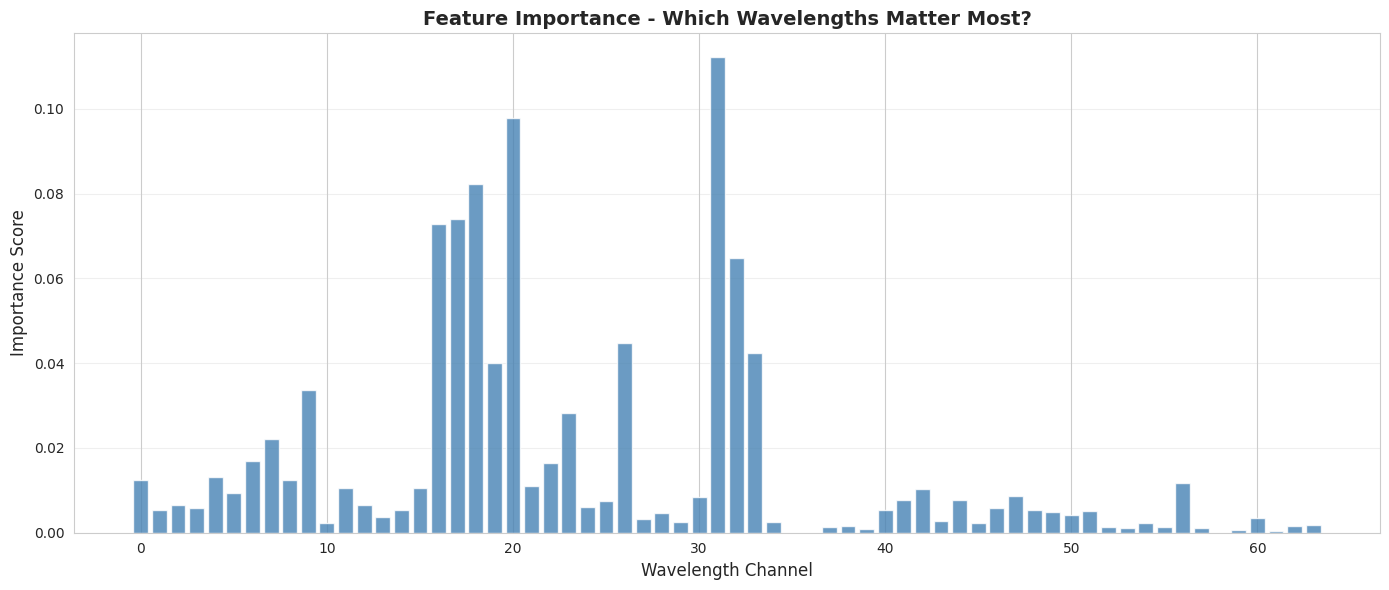


Top 10 Most Important Wavelength Channels:
1. Channel 31: importance = 0.1122
2. Channel 20: importance = 0.0979
3. Channel 18: importance = 0.0822
4. Channel 17: importance = 0.0741
5. Channel 16: importance = 0.0728
6. Channel 32: importance = 0.0648
7. Channel 26: importance = 0.0448
8. Channel 33: importance = 0.0423
9. Channel 19: importance = 0.0401
10. Channel 9: importance = 0.0338


In [99]:
# Get feature importance
feature_importance = best_model.feature_importances_

plt.figure(figsize=(14, 6))
plt.bar(range(len(feature_importance)), feature_importance, color='steelblue', alpha=0.8)
plt.xlabel('Wavelength Channel', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.title('Feature Importance - Which Wavelengths Matter Most?', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 10 most important channels
top_features = np.argsort(feature_importance)[-10:][::-1]
print("\nTop 10 Most Important Wavelength Channels:")
for i, idx in enumerate(top_features, 1):
    print(f"{i}. Channel {idx}: importance = {feature_importance[idx]:.4f}")

# Exercise

Repeat the above workflow but using the functions that generate a much more 'noisy' spectra provided below. You can begin with the function:

```python
generate_uvlif_spectrum_hard
```
and proceed from there. If you run the code block below (which you need to do anyway to make the functions available to the interpreter), you will be able to infer the difference between spectra.

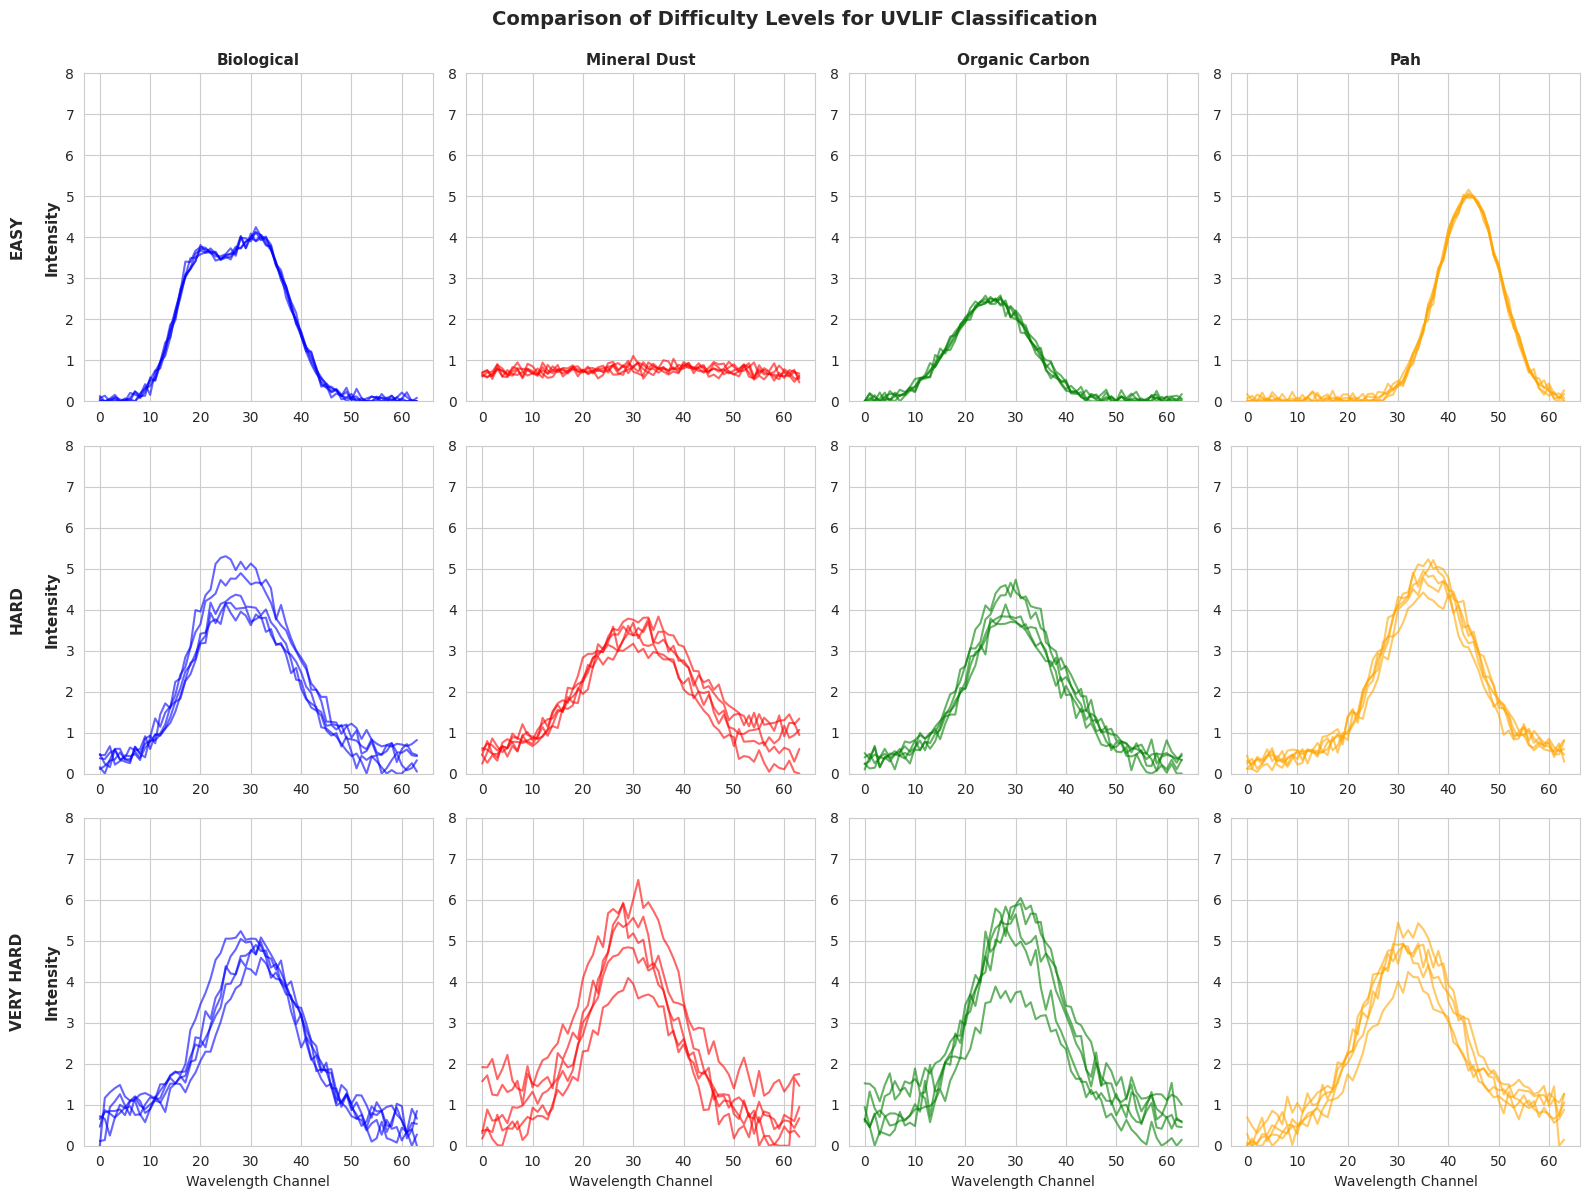

Difficulty Levels Created:

1. EASY (original function):
   - Well-separated spectral features
   - Distinct peak positions
   - Low noise
   - Expected accuracy: 97-99%

2. HARD (generate_uvlif_spectrum_hard):
   - Overlapping peak positions
   - Similar intensities between classes
   - Moderate noise + baseline drift
   - Intensity scaling variability
   - Expected accuracy: 85-92%

3. VERY HARD (generate_uvlif_spectrum_very_hard):
   - Minimal peak position differences
   - Differences mainly in peak ratios
   - High noise + significant baseline drift
   - Peak position jitter (calibration drift)
   - Large intensity variability
   - Expected accuracy: 70-85%



In [100]:
def generate_uvlif_spectrum_hard(aerosol_type, n_wavelengths=64, noise_level=0.15):
    """
    Generate synthetic UVLIF spectrum with more subtle differences between classes.
    This creates a more challenging classification problem.

    Parameters:
    -----------
    aerosol_type : str
        Type of aerosol ('biological', 'mineral_dust', 'organic_carbon', 'pah')
    n_wavelengths : int
        Number of spectral channels (wavelength bins)
    noise_level : float
        Amount of random noise to add (increased from easy version)
    """
    wavelengths = np.linspace(0, 1, n_wavelengths)

    # All classes now have overlapping spectral features
    # Main differences are in relative intensities and subtle peak positions

    if aerosol_type == 'biological':
        # Two peaks but at similar positions to organic carbon
        # Peak 1: slightly shifted from organic carbon
        peak1 = 2.5 * np.exp(-((wavelengths - 0.35)**2) / 0.015)
        # Peak 2: moderate intensity
        peak2 = 3.0 * np.exp(-((wavelengths - 0.52)**2) / 0.025)
        # Small broad background
        background = 0.8 * np.exp(-((wavelengths - 0.5)**2) / 0.3)
        spectrum = peak1 + peak2 + background

    elif aerosol_type == 'mineral_dust':
        # No longer very flat - has similar broad features to others
        # Broad peak similar position to biological but weaker
        peak1 = 1.2 * np.exp(-((wavelengths - 0.38)**2) / 0.02)
        peak2 = 1.8 * np.exp(-((wavelengths - 0.55)**2) / 0.03)
        # Stronger background than before
        background = 1.0 * np.exp(-((wavelengths - 0.5)**2) / 0.4)
        spectrum = peak1 + peak2 + background

    elif aerosol_type == 'organic_carbon':
        # Single peak but overlaps with biological peak positions
        # Peak position between biological peaks
        peak1 = 2.8 * np.exp(-((wavelengths - 0.42)**2) / 0.022)
        # Small secondary feature
        peak2 = 1.5 * np.exp(-((wavelengths - 0.58)**2) / 0.028)
        # Moderate background
        background = 0.7 * np.exp(-((wavelengths - 0.5)**2) / 0.35)
        spectrum = peak1 + peak2 + background

    elif aerosol_type == 'pah':
        # Shifted closer to organic carbon region
        # Main peak not as far in the red anymore
        peak1 = 1.8 * np.exp(-((wavelengths - 0.48)**2) / 0.02)
        peak2 = 3.2 * np.exp(-((wavelengths - 0.62)**2) / 0.025)
        # Similar background
        background = 0.6 * np.exp(-((wavelengths - 0.55)**2) / 0.35)
        spectrum = peak1 + peak2 + background

    # Add MORE noise (increased from 0.1 to 0.15 default)
    noise = noise_level * np.random.randn(n_wavelengths)
    spectrum = spectrum + noise

    # Add some random baseline drift to make it harder
    baseline_drift = 0.3 * np.random.randn() * np.linspace(0, 1, n_wavelengths)
    spectrum = spectrum + baseline_drift

    # Ensure non-negative
    spectrum = np.maximum(spectrum, 0)

    # Add random intensity scaling (simulating instrument variability)
    intensity_scale = np.random.uniform(0.85, 1.15)
    spectrum = spectrum * intensity_scale

    return spectrum


# Alternative version: VERY HARD - even more overlap
def generate_uvlif_spectrum_very_hard(aerosol_type, n_wavelengths=64, noise_level=0.2):
    """
    Generate synthetic UVLIF spectrum with maximum overlap between classes.
    This creates an extremely challenging classification problem where classes
    differ mainly in subtle peak ratios and minor peak shifts.

    Parameters:
    -----------
    aerosol_type : str
        Type of aerosol ('biological', 'mineral_dust', 'organic_carbon', 'pah')
    n_wavelengths : int
        Number of spectral channels (wavelength bins)
    noise_level : float
        Amount of random noise to add
    """
    wavelengths = np.linspace(0, 1, n_wavelengths)

    # All classes share very similar spectral features
    # Differences are only in subtle peak ratios and minor position shifts

    # Common background for all classes
    background = 1.2 * np.exp(-((wavelengths - 0.5)**2) / 0.4)

    if aerosol_type == 'biological':
        # Peak ratio: 1.0:1.3
        peak1 = 2.0 * np.exp(-((wavelengths - 0.42)**2) / 0.02)
        peak2 = 2.6 * np.exp(-((wavelengths - 0.54)**2) / 0.025)
        spectrum = background + peak1 + peak2

    elif aerosol_type == 'mineral_dust':
        # Peak ratio: 1.2:1.0 (reversed from biological)
        peak1 = 2.4 * np.exp(-((wavelengths - 0.43)**2) / 0.02)
        peak2 = 2.0 * np.exp(-((wavelengths - 0.55)**2) / 0.025)
        spectrum = background + peak1 + peak2

    elif aerosol_type == 'organic_carbon':
        # Peak ratio: 1.1:1.1 (nearly equal)
        peak1 = 2.2 * np.exp(-((wavelengths - 0.41)**2) / 0.02)
        peak2 = 2.2 * np.exp(-((wavelengths - 0.53)**2) / 0.025)
        spectrum = background + peak1 + peak2

    elif aerosol_type == 'pah':
        # Peak ratio: 0.9:1.4 (second peak stronger)
        peak1 = 1.8 * np.exp(-((wavelengths - 0.44)**2) / 0.02)
        peak2 = 2.8 * np.exp(-((wavelengths - 0.56)**2) / 0.025)
        spectrum = background + peak1 + peak2

    # High noise
    noise = noise_level * np.random.randn(n_wavelengths)
    spectrum = spectrum + noise

    # Significant baseline drift
    baseline_drift = 0.5 * np.random.randn() * np.linspace(-1, 1, n_wavelengths)
    spectrum = spectrum + baseline_drift

    # Variable intensity scaling
    intensity_scale = np.random.uniform(0.75, 1.25)
    spectrum = spectrum * intensity_scale

    # Random small peak position jitter (simulating calibration drift)
    if np.random.rand() > 0.5:
        shift = np.random.randint(-2, 3)
        spectrum = np.roll(spectrum, shift)

    # Ensure non-negative
    spectrum = np.maximum(spectrum, 0)

    return spectrum


# ============================================================================
# DEMONSTRATION CODE - Compare difficulty levels
# ============================================================================

if __name__ == "__main__":
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_style('whitegrid')
    np.random.seed(42)

    aerosol_types = ['biological', 'mineral_dust', 'organic_carbon', 'pah']
    colors = ['blue', 'red', 'green', 'orange']

    # Create comparison figure
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    # Row 1: Easy (original)
    for idx, aerosol_type in enumerate(aerosol_types):
        for i in range(5):
            # Use original easy function
            spectrum = generate_uvlif_spectrum(aerosol_type)
            axes[0, idx].plot(spectrum, alpha=0.6, linewidth=1.5, color=colors[idx])
        axes[0, idx].set_title(f'{aerosol_type.replace("_", " ").title()}',
                               fontsize=11, fontweight='bold')
        axes[0, idx].set_ylim([0, 8])
        if idx == 0:
            axes[0, idx].set_ylabel('EASY\n\nIntensity', fontsize=11, fontweight='bold')

    # Row 2: Hard
    for idx, aerosol_type in enumerate(aerosol_types):
        for i in range(5):
            spectrum = generate_uvlif_spectrum_hard(aerosol_type)
            axes[1, idx].plot(spectrum, alpha=0.6, linewidth=1.5, color=colors[idx])
        axes[1, idx].set_ylim([0, 8])
        if idx == 0:
            axes[1, idx].set_ylabel('HARD\n\nIntensity', fontsize=11, fontweight='bold')

    # Row 3: Very Hard
    for idx, aerosol_type in enumerate(aerosol_types):
        for i in range(5):
            spectrum = generate_uvlif_spectrum_very_hard(aerosol_type)
            axes[2, idx].plot(spectrum, alpha=0.6, linewidth=1.5, color=colors[idx])
        axes[2, idx].set_xlabel('Wavelength Channel', fontsize=10)
        axes[2, idx].set_ylim([0, 8])
        if idx == 0:
            axes[2, idx].set_ylabel('VERY HARD\n\nIntensity', fontsize=11, fontweight='bold')

    plt.suptitle('Comparison of Difficulty Levels for UVLIF Classification',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('difficulty_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Difficulty Levels Created:")
    print("=" * 60)
    print("\n1. EASY (original function):")
    print("   - Well-separated spectral features")
    print("   - Distinct peak positions")
    print("   - Low noise")
    print("   - Expected accuracy: 97-99%")

    print("\n2. HARD (generate_uvlif_spectrum_hard):")
    print("   - Overlapping peak positions")
    print("   - Similar intensities between classes")
    print("   - Moderate noise + baseline drift")
    print("   - Intensity scaling variability")
    print("   - Expected accuracy: 85-92%")

    print("\n3. VERY HARD (generate_uvlif_spectrum_very_hard):")
    print("   - Minimal peak position differences")
    print("   - Differences mainly in peak ratios")
    print("   - High noise + significant baseline drift")
    print("   - Peak position jitter (calibration drift)")
    print("   - Large intensity variability")
    print("   - Expected accuracy: 70-85%")
    print("\n" + "=" * 60)

## Summary and Key Takeaways

### What We Learned:

1. **Data Splitting**
   - Training set: Learn patterns
   - Validation set: Tune hyperparameters
   - Test set: Final honest evaluation

2. **Model Evaluation**
   - Accuracy: Overall correct predictions
   - Confusion Matrix: Where errors occur
   - ROC/AUC: Trade-off between sensitivity and specificity
   - Precision/Recall: Class-specific performance

3. **Hyperparameter Tuning**
   - Grid search explores parameter combinations
   - Cross-validation prevents overfitting
   - Can significantly improve performance

4. **XGBoost Strengths**
   - Excellent for structured/tabular data
   - Handles complex patterns
   - Provides feature importance

### Next Steps:
In the next notebook, we'll use deep neural networks (DNNs) to tackle the same problem and compare approaches!

In [101]:
# Save the best model for potential future use
import pickle

with open('best_xgboost_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': scaler,
        'label_encoder': label_encoder
    }, f)

print("✓ Model saved to 'best_xgboost_model.pkl'")

✓ Model saved to 'best_xgboost_model.pkl'


### **Re-generating the Dataset with 'Harder' Spectra**

This code block re-creates our synthetic UVLIF aerosol dataset, but this time it uses the `generate_uvlif_spectrum_hard` function. This function is designed to produce spectra with more subtle differences between aerosol types, increased noise, and other complicating factors, making classification a more challenging task for the machine learning model.

-   `np.random.seed(42)`: Ensures that the random noise and variations added to the spectra are reproducible. If you run the code multiple times, you'll get the same 'random' results.
-   `n_samples_per_class_hard = 250`: Defines that we will generate 250 samples for each of the four aerosol types, resulting in a total of 1000 samples for the 'hard' dataset.
-   The `for` loops iterate through each `aerosol_type` and generate the specified number of `spectrum` samples using `generate_uvlif_spectrum_hard`.
-   The generated `spectrum` and `aerosol_type` (label) are stored in `data_hard` and `labels_hard` lists, respectively.
-   Finally, these lists are converted into NumPy arrays, `X_hard` for the spectral data (features) and `y_hard` for the aerosol type labels. This format is standard for machine learning libraries like scikit-learn.
-   The print statements confirm the shape of the new dataset and the classes being used.

In [102]:
# Re-generate dataset with 'harder' spectra

np.random.seed(42) # Ensure reproducibility
n_samples_per_class_hard = 250 # Using the same number of samples per class

data_hard = []
labels_hard = []

for aerosol_type in aerosol_types:
    for _ in range(n_samples_per_class_hard):
        spectrum = generate_uvlif_spectrum_hard(aerosol_type) # <--- Using the 'hard' function
        data_hard.append(spectrum)
        labels_hard.append(aerosol_type)

# Convert to arrays
X_hard = np.array(data_hard)
y_hard = np.array(labels_hard)

print(f"New Dataset shape: {X_hard.shape}")
print(f"Classes: {aerosol_types}")
print(f"Samples per class: {n_samples_per_class_hard}")

New Dataset shape: (1000, 64)
Classes: ['biological', 'mineral_dust', 'organic_carbon', 'pah']
Samples per class: 250


### **Visualizing Example Spectra for the 'Hard' Dataset**

This code block generates a visualization of several example spectra from the newly created `X_hard` dataset. The purpose is to visually compare these 'hard' spectra with the 'easy' spectra shown earlier in the notebook, highlighting the increased overlap and noise.

-   `plt.subplots(2, 2, figsize=(14, 10))`: Creates a figure with a 2x2 grid of subplots to display spectra for each of the four aerosol types.
-   `axes = axes.ravel()`: Flattens the 2x2 array of axes objects into a 1D array for easier iteration.
-   The `for` loop iterates through each `aerosol_type`.
-   `np.where(y_hard == aerosol_type)[0]`: Finds the indices in `y_hard` where the label matches the current `aerosol_type`. This allows us to select spectra belonging to that specific class.
-   An inner `for` loop plots the first 5 examples for each aerosol type onto its respective subplot (`axes[idx]`). The `alpha` and `linewidth` parameters adjust the appearance of the lines.
-   `axes[idx].set_title`, `set_xlabel`, `set_ylabel`, and `grid(True)`: Set titles, axis labels, and add a grid to each subplot for clarity.
-   `plt.tight_layout()`: Automatically adjusts subplot parameters for a tight layout, preventing labels from overlapping.
-   `plt.savefig(...)` and `plt.show()`: Save the generated figure to a file and display it in the notebook.

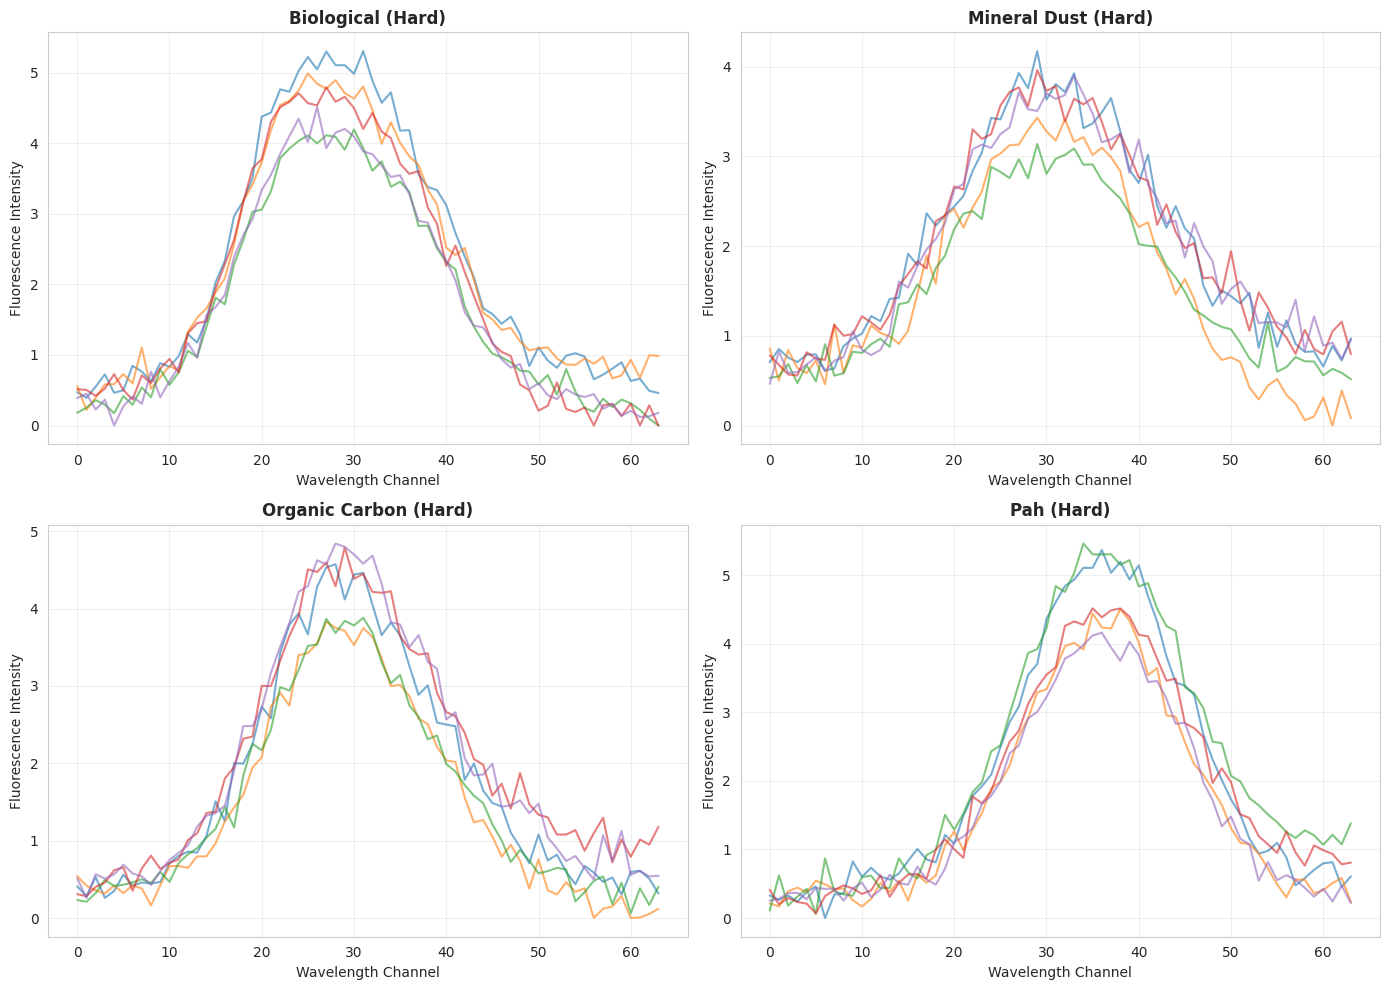

Note the increased overlap and noise compared to the 'easy' dataset.


In [94]:
# Visualize example spectra for each aerosol type in the 'hard' dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, aerosol_type in enumerate(aerosol_types):
    # Get indices for this class
    class_indices = np.where(y_hard == aerosol_type)[0]

    # Plot several examples
    for i in range(5):
        axes[idx].plot(X_hard[class_indices[i]], alpha=0.6, linewidth=1.5)

    axes[idx].set_title(f'{aerosol_type.replace("_", " ").title()} (Hard)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Wavelength Channel', fontsize=10)
    axes[idx].set_ylabel('Fluorescence Intensity', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('example_spectra_hard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note the increased overlap and noise compared to the 'easy' dataset.")

### **Re-performing Train/Test/Validation Split for 'Hard' Data**

This code block is crucial for preparing our 'hard' dataset for machine learning by dividing it into three distinct sets: training, validation, and testing. This ensures proper model development and evaluation, preventing data leakage and providing an unbiased estimate of performance.

-   **`train_test_split` function**: From `sklearn.model_selection`, this function is used to split arrays or matrices into random train and test subsets.
-   **First Split (Test Set)**:
    -   `X_hard`, `y_hard`: The full dataset (features and labels) generated in the previous step.
    -   `test_size=0.2`: 20% of the data is reserved for the final, unseen test set (`X_test_hard`, `y_test_hard`).
    -   `random_state=42`: Ensures reproducibility of the split. Running this code again will yield the exact same split.
    -   `stratify=y_hard`: This is very important for classification tasks. It ensures that the proportion of each aerosol type in the test set is the same as in the original `y_hard` dataset. This prevents scenarios where, by chance, one class might be underrepresented or overrepresented in a split.
-   The remaining 80% of the data is temporarily stored in `X_temp_hard` and `y_temp_hard`.
-   **Second Split (Train and Validation Sets)**:
    -   `X_temp_hard`, `y_temp_hard`: The data remaining after the first split.
    -   `test_size=0.25`: This means 25% of the *remaining* `X_temp_hard` (which is 80% of the total) will become the validation set. Mathematically, 25% of 80% is 20% of the total dataset.
    -   `random_state=42` and `stratify=y_temp_hard`: Again, for reproducibility and class proportion balance.
-   The result is a 60% training set (`X_train_hard`, `y_train_hard`), a 20% validation set (`X_val_hard`, `y_val_hard`), and a 20% test set (`X_test_hard`, `y_test_hard`).
-   The print statements confirm the size and percentage of samples in each split, and emphasize that the test set remains untouched until final evaluation.

In [103]:
# First split: separate out test set (20%) for 'hard' data
X_temp_hard, X_test_hard, y_temp_hard, y_test_hard = train_test_split(
    X_hard, y_hard, test_size=0.2, random_state=42, stratify=y_hard
)

# Second split: divide remaining data into train (60%) and validation (20%) for 'hard' data
X_train_hard, X_val_hard, y_train_hard, y_val_hard = train_test_split(
    X_temp_hard, y_temp_hard, test_size=0.25, random_state=42, stratify=y_temp_hard
)

print("Data splits for 'Hard' dataset:")
print(f"Training set: {X_train_hard.shape[0]} samples ({X_train_hard.shape[0]/len(X_hard)*100:.1f}%) ")
print(f"Validation set: {X_val_hard.shape[0]} samples ({X_val_hard.shape[0]/len(X_hard)*100:.1f}%) ")
print(f"Test set: {X_test_hard.shape[0]} samples ({X_test_hard.shape[0]/len(X_hard)*100:.1f}%) ")
print("\n✓ Test set is locked away - we won't touch it until final evaluation!")

Data splits for 'Hard' dataset:
Training set: 600 samples (60.0%) 
Validation set: 200 samples (20.0%) 
Test set: 200 samples (20.0%) 

✓ Test set is locked away - we won't touch it until final evaluation!


### **Feature Scaling and Label Encoding for 'Hard' Data**

This code block performs two essential preprocessing steps for our machine learning model:

1.  **Feature Scaling (Standardization)**: Many machine learning algorithms perform better when numerical input features are scaled to a standard range. `StandardScaler` standardizes features by removing the mean and scaling to unit variance. This means that for each feature (wavelength channel), its mean will become 0 and its standard deviation will become 1.
    -   `scaler_hard = StandardScaler()`: Initializes the scaler.
    -   `X_train_scaled_hard = scaler_hard.fit_transform(X_train_hard)`: **Crucially**, the `StandardScaler` is `fit` *only* on the training data (`X_train_hard`). This calculates the mean and standard deviation from the training data. Then, `transform` applies this scaling to the training data itself.
    -   `X_val_scaled_hard = scaler_hard.transform(X_val_hard)` and `X_test_scaled_hard = scaler_hard.transform(X_test_hard)`: The *same* scaler (with means and standard deviations learned from the training data) is then used to `transform` the validation and test sets. This prevents data leakage from the validation/test sets into the training process.

2.  **Label Encoding**: Machine learning models typically require numerical input for class labels, not strings. `LabelEncoder` converts categorical labels (like 'biological', 'mineral_dust') into numerical representations (e.g., 0, 1, 2, 3).
    -   `label_encoder_hard = LabelEncoder()`: Initializes the encoder.
    -   `y_train_encoded_hard = label_encoder_hard.fit_transform(y_train_hard)`: The `LabelEncoder` is `fit` on the training labels to discover all unique classes and assign them an integer. It then `transforms` these labels.
    -   `y_val_encoded_hard = label_encoder_hard.transform(y_val_hard)` and `y_test_encoded_hard = label_encoder_hard.transform(y_test_hard)`: The *same* encoder is used to `transform` the validation and test labels, ensuring consistent mapping.

After this block executes, your `X` datasets will be scaled, and your `y` datasets will be numerical, ready for model training.

In [104]:
# Feature scaling - fit scaler on training data only!
scaler_hard = StandardScaler()
X_train_scaled_hard = scaler_hard.fit_transform(X_train_hard)
X_val_scaled_hard = scaler_hard.transform(X_val_hard)
X_test_scaled_hard = scaler_hard.transform(X_test_hard)

# Encode labels
label_encoder_hard = LabelEncoder()
y_train_encoded_hard = label_encoder_hard.fit_transform(y_train_hard)
y_val_encoded_hard = label_encoder_hard.transform(y_val_hard)
y_test_encoded_hard = label_encoder_hard.transform(y_test_hard)

print("✓ 'Hard' data scaled and labels encoded")
print("\nNow you can proceed to re-run the 'Train a Baseline XGBoost Model' section (Step 3) and subsequent steps, using these new variables (`X_train_scaled_hard`, `y_train_encoded_hard`, etc.) to evaluate performance on the harder dataset.")

✓ 'Hard' data scaled and labels encoded

Now you can proceed to re-run the 'Train a Baseline XGBoost Model' section (Step 3) and subsequent steps, using these new variables (`X_train_scaled_hard`, `y_train_encoded_hard`, etc.) to evaluate performance on the harder dataset.


### **Training a Baseline XGBoost Model on 'Hard' Data**

This code block initializes and trains an XGBoost classifier with its default parameters, using the 'hard' training data we just preprocessed. This is our *baseline* model, which we'll later compare to a hyperparameter-tuned version.

-   `baseline_model = xgb.XGBClassifier(...)`: Creates an instance of the XGBoost classifier.
    -   `random_state=42`: Sets the random seed for reproducibility. This ensures that the internal random processes of XGBoost (like feature subsampling) yield the same results every time you run the code.
    -   `eval_metric='mlogloss'`: Specifies the evaluation metric to be used during training for multiclass classification problems. 'mlogloss' (multiclass log loss) is a common and robust metric for this type of problem, as it penalizes incorrect predictions more heavily when the model is very confident about them.
-   `baseline_model.fit(X_train_scaled_hard, y_train_encoded_hard)`: This is where the model learns. It takes the scaled features (`X_train_scaled_hard`) and their corresponding encoded labels (`y_train_encoded_hard`) to build its ensemble of decision trees.
-   `val_predictions = baseline_model.predict(X_val_scaled_hard)`: After training, the model predicts the classes for the validation set (`X_val_scaled_hard`). These predictions are used to assess the model's performance on unseen data *during development*.
-   `val_accuracy = (val_predictions == y_val_encoded_hard).mean()`: Calculates the accuracy by comparing the model's predictions to the true encoded labels of the validation set.
-   `classification_report(...)`: Generates a detailed report that includes precision, recall, and F1-score for each class, as well as overall accuracy, macro average, and weighted average. This gives a more nuanced view of performance than just accuracy, especially if classes are imbalanced. `target_names` ensures the report uses readable class names.

In [105]:
# Train baseline model with default parameters
baseline_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'  # multiclass log loss
)

baseline_model.fit(X_train_scaled_hard, y_train_encoded_hard)

# Evaluate on validation set
val_predictions = baseline_model.predict(X_val_scaled_hard)
val_accuracy = (val_predictions == y_val_encoded_hard).mean()

print(f"Baseline Model Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print("\nClassification Report (Validation Set):")
print(classification_report(y_val_encoded_hard, val_predictions,
                          target_names=label_encoder_hard.classes_))

Baseline Model Validation Accuracy: 0.9950 (99.50%)

Classification Report (Validation Set):
                precision    recall  f1-score   support

    biological       1.00      1.00      1.00        50
  mineral_dust       0.98      1.00      0.99        50
organic_carbon       1.00      0.98      0.99        50
           pah       1.00      1.00      1.00        50

      accuracy                           0.99       200
     macro avg       1.00      0.99      0.99       200
  weighted avg       1.00      0.99      0.99       200



### **Visualizing the Confusion Matrix for the Baseline Model (Hard Data)**

This code block generates and displays a confusion matrix, a powerful tool for understanding the performance of a classification model, especially for multi-class problems. For the 'hard' dataset, this matrix will reveal where the model is making errors.

-   `cm = confusion_matrix(y_val_encoded_hard, val_predictions)`: Calculates the confusion matrix. It compares the true labels (`y_val_encoded_hard`) with the model's predicted labels (`val_predictions`) on the validation set.
    -   Each row in the matrix represents the instances in an actual class.
    -   Each column represents the instances in a predicted class.
    -   The diagonal elements show the number of correct predictions for each class.
    -   Off-diagonal elements show the number of misclassifications.
-   `sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ...)`: Uses Seaborn to create a visually appealing heatmap of the confusion matrix.
    -   `annot=True`: Displays the numerical values in each cell.
    -   `fmt='d'`: Formats the annotations as integers.
    -   `cmap='Blues'`: Uses a blue color scheme, where darker shades indicate higher values.
    -   `xticklabels=label_encoder_hard.classes_`, `yticklabels=label_encoder_hard.classes_`: Ensures that the axis labels show the actual aerosol type names (e.g., 'biological', 'mineral_dust') instead of their numerical encodings (0, 1, 2, 3), making the matrix much easier to interpret.
-   `plt.title`, `plt.ylabel`, `plt.xlabel`: Set the title and axis labels for clarity.
-   `plt.tight_layout()`: Adjusts plot parameters for a tight layout.
-   `plt.savefig(...)` and `plt.show()`: Save and display the plot.

The output will show a grid where you can quickly see which aerosol types are being correctly identified and which are being confused with others.

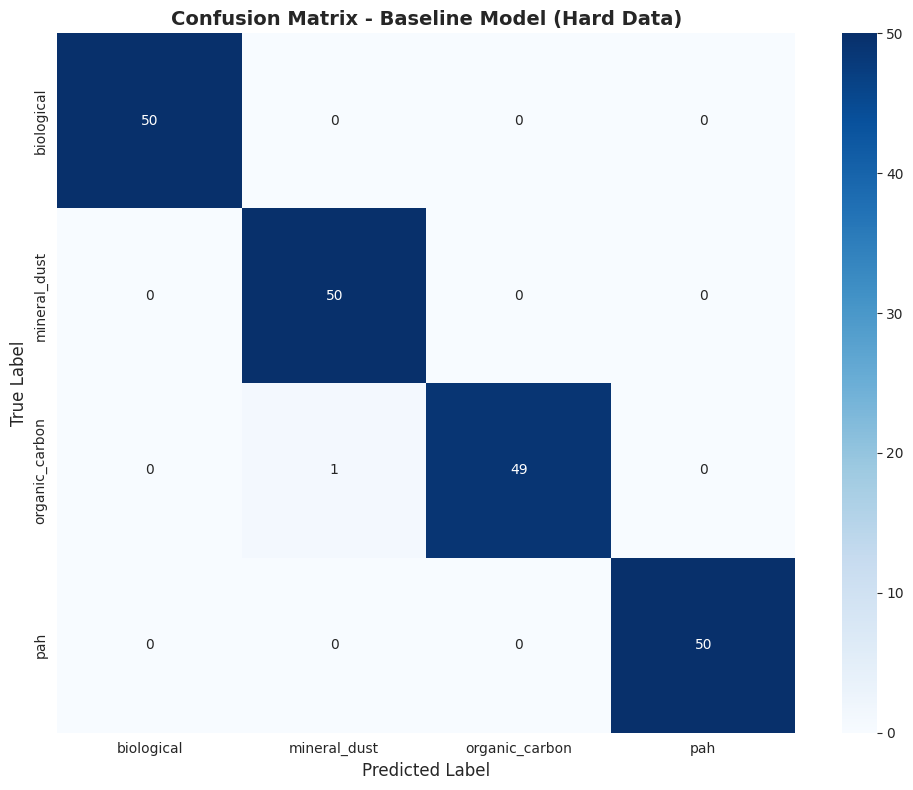


How to read this: Diagonal = correct predictions, Off-diagonal = errors


In [106]:
# Confusion Matrix
cm = confusion_matrix(y_val_encoded_hard, val_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_hard.classes_,
            yticklabels=label_encoder_hard.classes_)
plt.title('Confusion Matrix - Baseline Model (Hard Data)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_baseline_hard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHow to read this: Diagonal = correct predictions, Off-diagonal = errors")

### **Plotting ROC Curves and Calculating AUC for the Baseline Model (Hard Data)**

This code block generates Receiver Operating Characteristic (ROC) curves and calculates the Area Under the Curve (AUC) for each class in our multi-class classification problem. This helps us understand the model's ability to distinguish between classes at various classification thresholds, which is particularly useful for the 'hard' dataset.

-   `y_val_proba = baseline_model.predict_proba(X_val_scaled_hard)`: Instead of just predicting the final class, this retrieves the predicted probabilities for each class for the validation set. For example, for a sample, it might output `[0.1, 0.8, 0.05, 0.05]`, indicating an 80% chance of being class 1.
-   `y_val_bin = label_binarize(y_val_encoded_hard, classes=range(len(aerosol_types)))`: To compute ROC curves for multi-class problems, we often use a "one-vs-rest" (OvR) approach. This function converts the true encoded labels into a binary format where each column represents one class. For example, if `y_val_encoded_hard` is `[0, 1, 2]`, `y_val_bin` might be `[[1,0,0], [0,1,0], [0,0,1]]`.
-   The `for` loop iterates through each class (aerosol type):
    -   `roc_curve(y_val_bin[:, i], y_val_proba[:, i])`: Calculates the False Positive Rate (FPR) and True Positive Rate (TPR) for each class `i`. The FPR is the rate of incorrect positive predictions, and the TPR is the rate of correct positive predictions.
    -   `auc(fpr[i], tpr[i])`: Computes the Area Under the Curve (AUC) for the ROC curve of class `i`. AUC ranges from 0 to 1, where 1 is a perfect classifier and 0.5 is equivalent to random guessing.
-   The second `for` loop then plots each ROC curve using `plt.plot()`, assigning a distinct color and including the calculated AUC in the legend.
-   `plt.plot([0, 1], [0, 1], 'k--', ...)`: Adds a diagonal dashed line representing a random classifier (AUC = 0.5) for comparison.
-   `plt.xlim`, `plt.ylim`, `plt.xlabel`, `plt.ylabel`, `plt.title`, `plt.legend`, `plt.grid`: Standard Matplotlib commands to customize the plot's appearance.
-   `plt.savefig(...)` and `plt.show()`: Save and display the plot.

The output will show a separate curve for each aerosol type. Curves that hug the top-left corner (high TPR, low FPR) indicate better performance for that class. Higher AUC values signify a better ability to distinguish between positive and negative classes.

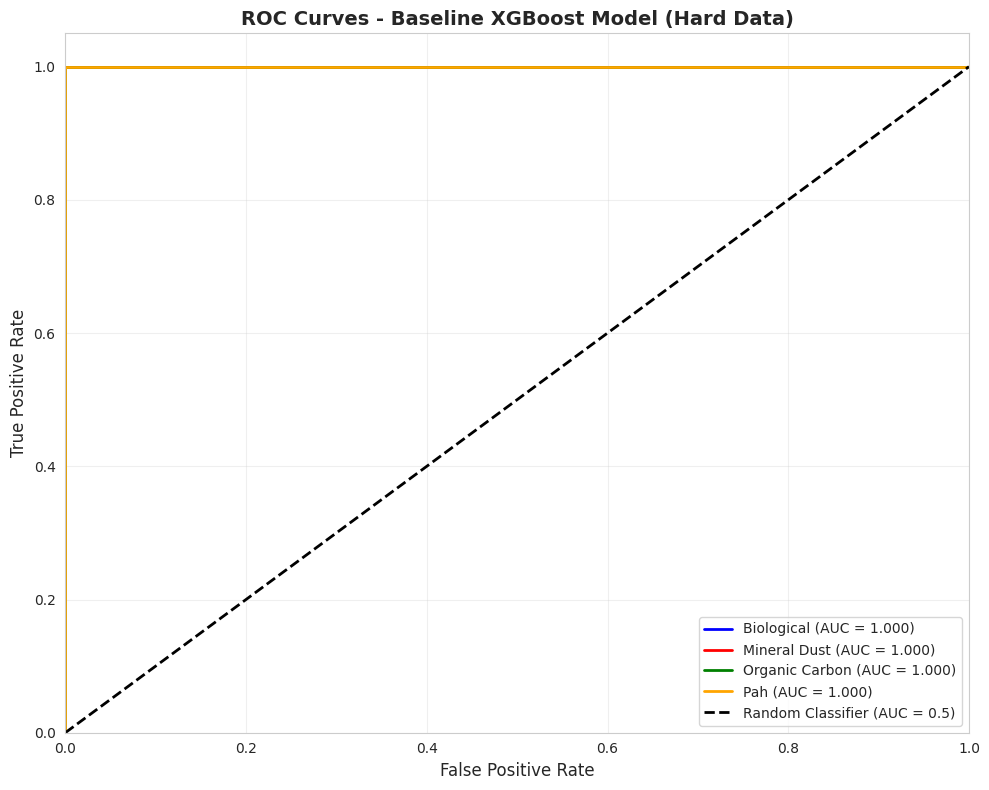


Interpretation:
- Curves closer to top-left corner = better performance
- AUC closer to 1.0 = better discrimination ability
- Mean AUC across classes: 1.000


In [107]:
# Get probability predictions
y_val_proba = baseline_model.predict_proba(X_val_scaled_hard)

# Binarize labels for ROC curve (one-vs-rest)
y_val_bin = label_binarize(y_val_encoded_hard, classes=range(len(aerosol_types)))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(aerosol_types)):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']

for i, (color, aerosol_type) in enumerate(zip(colors, aerosol_types)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{aerosol_type.replace("_", " ").title()} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Baseline XGBoost Model (Hard Data)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_baseline_hard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Curves closer to top-left corner = better performance")
print("- AUC closer to 1.0 = better discrimination ability")
print(f"- Mean AUC across classes: {np.mean(list(roc_auc.values())):.3f}")

### **Hyperparameter Tuning with Grid Search and Cross-Validation for 'Hard' Data**

This code block performs hyperparameter tuning to find the optimal settings for our XGBoost model when dealing with the 'hard' dataset. Hyperparameters are parameters that are *not* learned from the data during training but are set *before* training. Tuning them can significantly improve model performance.

-   **`param_grid`**: This dictionary defines the range of hyperparameters and their values that `GridSearchCV` will explore:
    -   `n_estimators`: The number of boosting rounds or trees to build. More trees can increase accuracy but also computation time and risk of overfitting.
    -   `max_depth`: The maximum depth of each individual decision tree. Deeper trees can capture more complex relationships but are more prone to overfitting.
    -   `learning_rate`: Controls the step size shrinkage to prevent overfitting. Smaller values require more `n_estimators`.
    -   `subsample`: The fraction of samples used to train each tree. This helps prevent overfitting by introducing randomness.
-   `xgb_model = xgb.XGBClassifier(...)`: Initializes an XGBoost classifier with a `random_state` for reproducibility and `eval_metric='mlogloss'`.
-   **`GridSearchCV`**: This powerful tool automates the process of finding the best hyperparameters.
    -   `estimator=xgb_model`: The model we want to tune.
    -   `param_grid=param_grid`: The dictionary of hyperparameters and values to test.
    -   `cv=5`: Specifies 5-fold cross-validation. This means the training data (`X_train_scaled_hard`) will be split into 5 parts. The model will be trained 5 times; each time, it uses 4 parts for training and 1 part for validation. This helps to get a more robust estimate of performance for each parameter combination and prevents overfitting to a single training/validation split.
    -   `scoring='accuracy'`: The metric used to evaluate each parameter combination during cross-validation.
    -   `n_jobs=-1`: Uses all available CPU cores, speeding up the search process.
    -   `verbose=1`: Prints progress messages during the search.
-   `grid_search.fit(X_train_scaled_hard, y_train_encoded_hard)`: Executes the grid search. It trains and evaluates an XGBoost model for *every combination* of hyperparameters defined in `param_grid` using 5-fold cross-validation on the `X_train_scaled_hard` and `y_train_encoded_hard` data.
-   The print statements output the best parameters found, the best cross-validation score achieved, the baseline validation score for comparison, and the improvement (or degradation) in performance.

In [76]:
# Define parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

print(f"Testing {np.prod([len(v) for v in param_grid.values()])} parameter combinations...")
print("This may take a few minutes...\n")

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Fit on training data
grid_search.fit(X_train_scaled_hard, y_train_encoded_hard)

print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Baseline Validation Score: {val_accuracy:.4f}")
print(f"\nImprovement: {(grid_search.best_score_ - val_accuracy)*100:.2f} percentage points")

Testing 54 parameter combinations...
This may take a few minutes...

Fitting 5 folds for each of 54 candidates, totalling 270 fits

HYPERPARAMETER TUNING RESULTS

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Score: 0.9800
Baseline Validation Score: 0.9950

Improvement: -1.50 percentage points


### **Evaluating the Tuned Model on the Validation Set (Hard Data)**

After `GridSearchCV` has completed, this code block retrieves the best model (the one that performed best during cross-validation) and evaluates its performance on the validation set for the 'hard' data. This is a crucial step to see if the hyperparameter tuning actually improved the model's ability to generalize compared to the baseline model.

-   `best_model = grid_search.best_estimator_`: After `grid_search.fit()` finishes, the `grid_search` object stores the best model found (the estimator with the best parameters) in its `best_estimator_` attribute. We assign this model to `best_model`.
-   `val_predictions_tuned = best_model.predict(X_val_scaled_hard)`: The `best_model` is then used to make predictions on the scaled features of the validation set (`X_val_scaled_hard`).
-   `val_accuracy_tuned = (val_predictions_tuned == y_val_encoded_hard).mean()`: The accuracy of these predictions is calculated by comparing them to the true encoded labels of the validation set (`y_val_encoded_hard`).
-   The print statements display the validation accuracy of the tuned model, allowing for a direct comparison with the baseline model's validation accuracy. This helps determine if the hyperparameter tuning was successful.
-   `classification_report(...)`: Similar to the baseline model evaluation, a detailed classification report is printed, providing precision, recall, and F1-score for each class, offering a comprehensive view of the tuned model's performance on the validation set.

In [77]:
# Get best model
best_model = grid_search.best_estimator_

# Evaluate on validation set
val_predictions_tuned = best_model.predict(X_val_scaled_hard)
val_accuracy_tuned = (val_predictions_tuned == y_val_encoded_hard).mean()

print("\nTuned Model Performance:")
print("="*60)
print(f"Validation Accuracy: {val_accuracy_tuned:.4f} ({val_accuracy_tuned*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_val_encoded_hard, val_predictions_tuned,
                          target_names=label_encoder_hard.classes_))


Tuned Model Performance:
Validation Accuracy: 1.0000 (100.00%)

Classification Report:
                precision    recall  f1-score   support

    biological       1.00      1.00      1.00        50
  mineral_dust       1.00      1.00      1.00        50
organic_carbon       1.00      1.00      1.00        50
           pah       1.00      1.00      1.00        50

      accuracy                           1.00       200
     macro avg       1.00      1.00      1.00       200
  weighted avg       1.00      1.00      1.00       200



### **Comparing ROC Curves: Baseline vs. Tuned Model (Hard Data)**

This code block generates two sets of ROC curves (Receiver Operating Characteristic) for the 'hard' dataset: one for the baseline XGBoost model and one for the hyperparameter-tuned model. This visual comparison helps to understand if the tuning process has improved the model's ability to discriminate between classes.

-   `y_val_proba_tuned = best_model.predict_proba(X_val_scaled_hard)`: This obtains the predicted probabilities for each class from the `best_model` (the tuned model) on the scaled validation data.
-   `fig, axes = plt.subplots(1, 2, figsize=(16, 6))`: Creates a figure with two subplots side-by-side, one for the baseline model's ROC curves and one for the tuned model's.
-   **Plotting for Baseline Model (Left Subplot)**:
    -   It iterates through each aerosol type.
    -   `fpr_base, tpr_base, _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])`: Recalculates (or reuses) the False Positive Rate (FPR) and True Positive Rate (TPR) for the *baseline* model's probabilities (`y_val_proba`) for each class.
    -   `roc_auc_base = auc(fpr_base, tpr_base)`: Computes the AUC for the baseline model's ROC curve for the current class.
    -   `axes[0].plot(...)`: Plots the ROC curve on the first subplot, showing the AUC in the legend.
    -   `axes[0].plot([0, 1], [0, 1], 'k--', ...)`: Adds the random classifier line for reference.
    -   Titles and labels are set for clarity.
-   **Plotting for Tuned Model (Right Subplot)**:
    -   Similar to the baseline plot, but uses `y_val_proba_tuned` (probabilities from the tuned model) to calculate and plot the ROC curves on the second subplot (`axes[1]`).
    -   It also calculates `roc_auc_tuned` for the tuned model.
-   `plt.tight_layout()`: Adjusts layout to prevent overlaps.
-   `plt.savefig(...)` and `plt.show()`: Saves and displays the comparative plot.

By comparing the shapes and AUC values of the curves in the two plots, you can visually assess whether the hyperparameter tuning led to better class discrimination, especially for the 'hard' dataset where distinctions might be subtle.

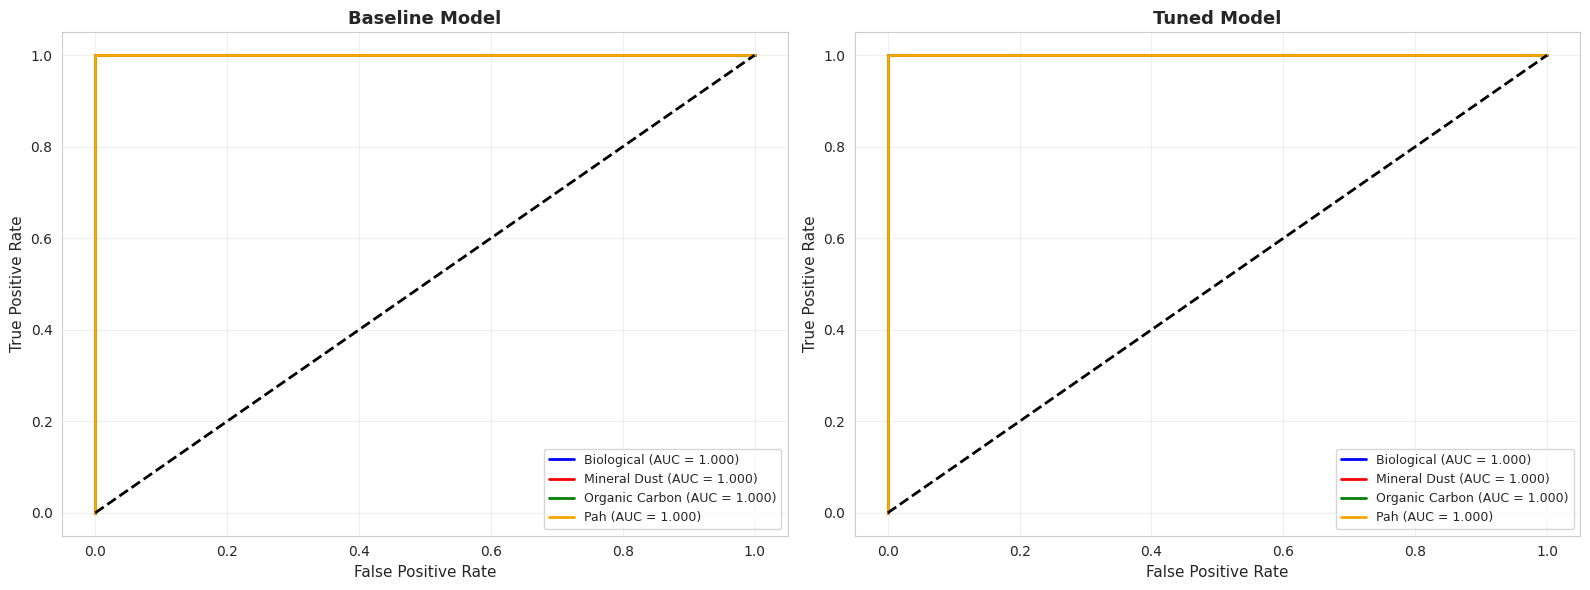

In [78]:
# Compare ROC curves: Baseline vs Tuned
y_val_proba_tuned = best_model.predict_proba(X_val_scaled_hard)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for baseline
for i, (color, aerosol_type) in enumerate(zip(colors, aerosol_types)):
    fpr_base, tpr_base, _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc_base = auc(fpr_base, tpr_base)
    axes[0].plot(fpr_base, tpr_base, color=color, lw=2,
                label=f'{aerosol_type.replace("_", " ").title()} (AUC = {roc_auc_base:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Baseline Model', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot for tuned model
for i, (color, aerosol_type) in enumerate(zip(colors, aerosol_types)):
    fpr_tuned, tpr_tuned, _ = roc_curve(y_val_bin[:, i], y_val_proba_tuned[:, i])
    roc_auc_tuned = auc(fpr_tuned, tpr_tuned)
    axes[1].plot(fpr_tuned, tpr_tuned, color=color, lw=2,
                label=f'{aerosol_type.replace("_", " ").title()} (AUC = {roc_auc_tuned:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Tuned Model', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### **Final Evaluation on the Test Set (Hard Data)**

This is the most critical step in evaluating our model. After all the development and tuning using the training and validation sets, we finally use the completely held-out test set (`X_test_scaled_hard`, `y_test_encoded_hard`) to get an unbiased estimate of how our best model will perform on new, unseen data from the 'hard' distribution. This is considered the "honest estimate" of the model's real-world performance.

-   `test_predictions = best_model.predict(X_test_scaled_hard)`: The `best_model` (our hyperparameter-tuned model) makes predictions on the scaled features of the test set.
-   `test_accuracy = (test_predictions == y_test_encoded_hard).mean()`: The overall accuracy on the test set is calculated by comparing the predictions to the true encoded labels.
-   The print statements display the final test set accuracy, which is the most important metric for generalization.
-   `classification_report(...)`: A full classification report is generated for the test set, providing precision, recall, and F1-score for each class. This helps identify any class-specific performance issues that might appear on truly unseen data.
-   **Test set confusion matrix**: A confusion matrix (`cm_test`) is generated and visualized using Seaborn, similar to the validation set confusion matrix. This provides a visual breakdown of correct and incorrect predictions for each class on the final test set, using `label_encoder_hard.classes_` for clear labels.

This evaluation tells us how well our model, optimized for the 'hard' data, is expected to perform in a real-world scenario where it encounters similar, challenging aerosol spectra.

FINAL TEST SET EVALUATION

Test Set Accuracy: 1.0000 (100.00%)

Classification Report:
                precision    recall  f1-score   support

    biological       1.00      1.00      1.00        50
  mineral_dust       1.00      1.00      1.00        50
organic_carbon       1.00      1.00      1.00        50
           pah       1.00      1.00      1.00        50

      accuracy                           1.00       200
     macro avg       1.00      1.00      1.00       200
  weighted avg       1.00      1.00      1.00       200



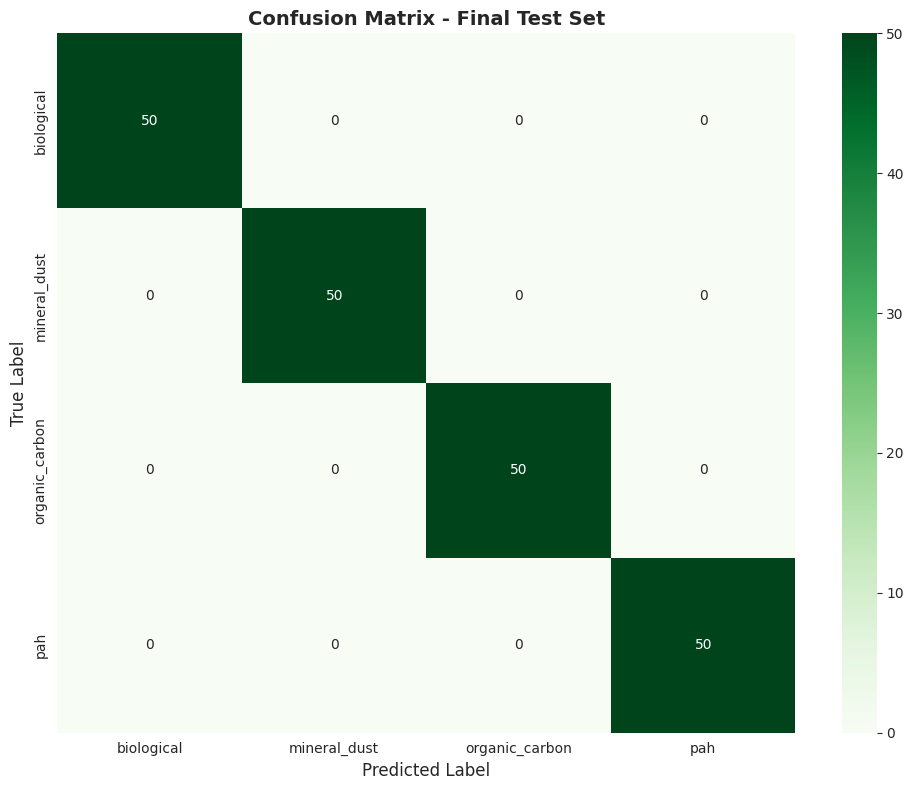

In [79]:
# Final evaluation on test set
test_predictions = best_model.predict(X_test_scaled_hard)
test_accuracy = (test_predictions == y_test_encoded_hard).mean()

print("="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)
print(f"\nTest Set Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test_encoded_hard, test_predictions,
                          target_names=label_encoder_hard.classes_))

# Test set confusion matrix
cm_test = confusion_matrix(y_test_encoded_hard, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder_hard.classes_,
            yticklabels=label_encoder_hard.classes_)
plt.title('Confusion Matrix - Final Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

### **Analyzing Feature Importance for the Tuned Model (Hard Data)**

This code block extracts and visualizes the feature importances from our best-performing XGBoost model trained on the 'hard' data. For spectral data, "features" correspond to the different wavelength channels. This analysis helps us understand which parts of the spectrum (which wavelength channels) the model found most influential in distinguishing between aerosol types.

-   `feature_importance = best_model.feature_importances_`: XGBoost models (and tree-based models in general) can provide a score for each feature indicating its relative importance in making predictions. This line retrieves these scores from our `best_model`.
-   `plt.figure(figsize=(14, 6))`: Creates a figure for the bar plot.
-   `plt.bar(range(len(feature_importance)), feature_importance, ...)`: Generates a bar plot where:
    -   The x-axis (`range(len(feature_importance))`) represents the index of each wavelength channel (feature).
    -   The y-axis (`feature_importance`) represents the importance score assigned to that channel by the model.
-   Labels, title, and grid are added for readability.
-   `plt.tight_layout()`: Adjusts plot parameters for a tight layout.
-   `plt.savefig(...)` and `plt.show()`: Save and display the plot.
-   **Top 10 Most Important Channels**: After plotting, the code identifies and prints the top 10 most important wavelength channels.
    -   `np.argsort(feature_importance)`: Returns the indices that would sort the `feature_importance` array in ascending order.
    -   `[-10:][::-1]`: Selects the last 10 (which are the largest importance scores) and then reverses them to get the top 10 in descending order of importance.
    -   The loop then prints the channel index and its importance score.

This visualization and list help aerosol scientists understand which spectral regions are most critical for distinguishing aerosol types, potentially providing insights into the underlying physical or chemical properties being measured.

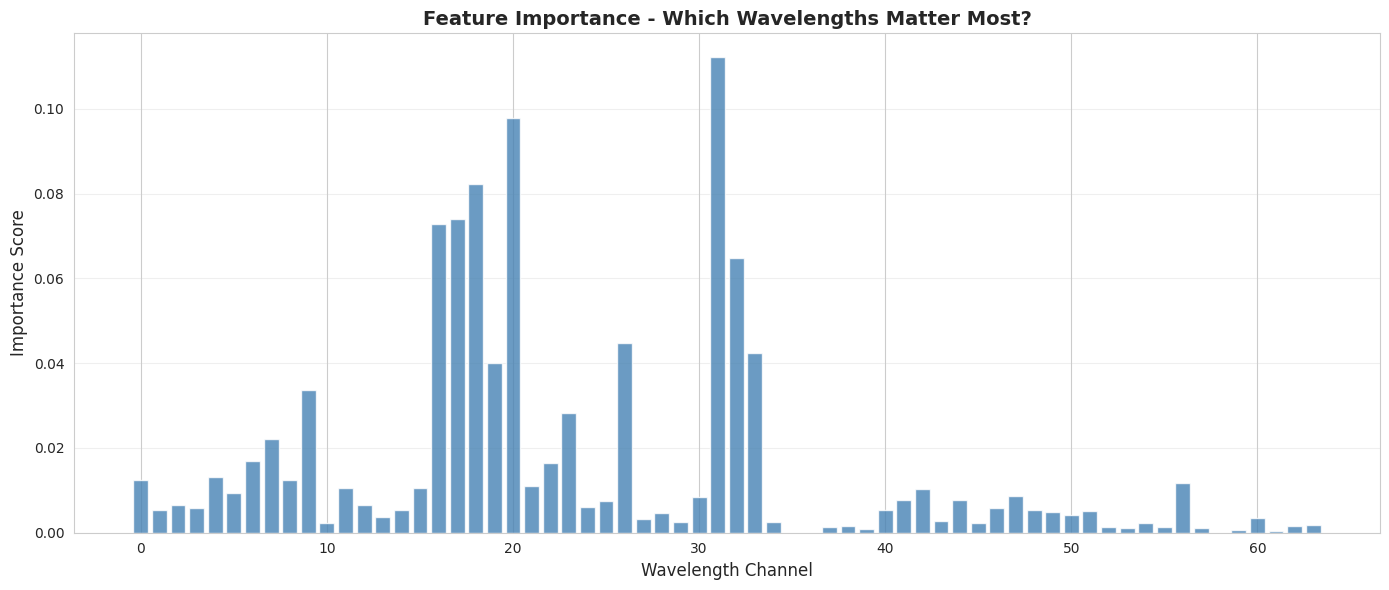


Top 10 Most Important Wavelength Channels:
1. Channel 31: importance = 0.1122
2. Channel 20: importance = 0.0979
3. Channel 18: importance = 0.0822
4. Channel 17: importance = 0.0741
5. Channel 16: importance = 0.0728
6. Channel 32: importance = 0.0648
7. Channel 26: importance = 0.0448
8. Channel 33: importance = 0.0423
9. Channel 19: importance = 0.0401
10. Channel 9: importance = 0.0338


In [80]:
# Get feature importance
feature_importance = best_model.feature_importances_

plt.figure(figsize=(14, 6))
plt.bar(range(len(feature_importance)), feature_importance, color='steelblue', alpha=0.8)
plt.xlabel('Wavelength Channel', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.title('Feature Importance - Which Wavelengths Matter Most?', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 10 most important channels
top_features = np.argsort(feature_importance)[-10:][::-1]
print("\nTop 10 Most Important Wavelength Channels:")
for i, idx in enumerate(top_features, 1):
    print(f"{i}. Channel {idx}: importance = {feature_importance[idx]:.4f}")